## Metrics 

In [1]:
import pandas as pd
from pathlib import Path
GEN_PATH = '../../01_data/2_cleaned/generation/hourly_solar_wind_generation_2020_2025.parquet'
LOAD_PATH = '../../01_data/2_cleaned/load/total_load_20201231_20260526.csv'
CAPACITY_PATH = '../../01_data/2_cleaned/generation/ERCOT nonRE capacity 2020-2025.csv'
PRICE_PATH = '../../01_data/2_cleaned/rtm_price/rtm_price_aggregated_2021_2025.csv'

OUT_DIR = Path('../../01_data/3_analysis/price incentive metrics')

In [2]:
# merge datasets
df_gen = pd.read_parquet(GEN_PATH)
df_gen['datetime'] = pd.to_datetime(df_gen['datetime'])
df_gen.head()

,datetime,renewable_gen
0,2020-01-01 01:00:00,12832.85
1,2020-01-01 02:00:00,13328.73
2,2020-01-01 03:00:00,13920.06
3,2020-01-01 04:00:00,14443.91
4,2020-01-01 05:00:00,14713.70


In [3]:
df_load = pd.read_csv(LOAD_PATH)
df_load['datetime'] = pd.to_datetime(df_load['datetime'])
df_load.head()

,datetime,total_load
0,2020-12-31 01:00:00,39174.39
1,2020-12-31 02:00:00,38284.84
2,2020-12-31 03:00:00,37776.69
3,2020-12-31 04:00:00,37781.84
4,2020-12-31 05:00:00,38455.69


In [4]:
df_capacity = pd.read_csv(CAPACITY_PATH)
df_total_cap = df_capacity.filter(['year', 'total_mw'])
df_total_cap = df_total_cap.rename(columns={'total_mw': 'non_re_capacity'})
df_total_cap['non_re_capacity'] = df_total_cap['non_re_capacity'].astype(int)
df_total_cap

,year,non_re_capacity
0,2020,65518
1,2021,66390
2,2022,67023
3,2023,68028
4,2024,68766
5,2025,68624


In [5]:
df_price = pd.read_csv(PRICE_PATH)
df_price = df_price.filter(['date_time', 'avg_rtm_price'])
df_price = df_price.rename(columns={'date_time': 'datetime', 'avg_rtm_price' : 'rtm_price'})
df_price['datetime'] = pd.to_datetime(df_price['datetime'])
df_price.describe()

,datetime,rtm_price
count,43315,43315.000000
mean,2023-07-02 13:27:46.729770,66.584313
min,2021-01-01 01:00:00,-2.656667
25%,2022-04-03 07:30:00,19.183333
50%,2023-07-05 13:00:00,27.560000
75%,2024-09-29 18:30:00,43.636000
max,2025-12-28 00:00:00,9001.180667
std,NaN,418.440833


### Metric calculation

In [6]:
import duckdb
con = duckdb.connect()
df_metric = con.execute("""
   WITH Merged AS (
      SELECT
         g.datetime
         ,renewable_gen
         ,total_load
         ,non_re_capacity
      FROM df_gen g
      INNER JOIN df_load l ON g.datetime = l.datetime
      LEFT JOIN df_total_cap c ON YEAR(g.datetime) = c.year                     
      )
   
   SELECT
         datetime
         ,(total_load - renewable_gen)/non_re_capacity AS metric1
   FROM Merged;
""").fetchdf()

df_metric

,datetime,metric1
0,2020-12-31 01:00:00,0.353749
1,2020-12-31 02:00:00,0.339487
2,2020-12-31 03:00:00,0.352268
3,2020-12-31 04:00:00,0.360650
4,2020-12-31 05:00:00,0.379511
...,...,...
43817,2025-12-31 20:00:00,0.580351
43818,2025-12-31 21:00:00,0.523718
43819,2025-12-31 22:00:00,0.475877
43820,2025-12-31 23:00:00,0.428662


In [8]:
# price metrics

df_price = con.execute("""
    SELECT
        datetime
        ,AVG(rtm_price) OVER (
                        ORDER BY datetime 
                        RANGE BETWEEN INTERVAL '7 days' PRECEDING AND CURRENT ROW
                        ) AS rolling_avg_price
        ,MAX(rtm_price) OVER (PARTITION BY CAST(datetime AS DATE))
         - MIN(rtm_price) OVER (PARTITION BY CAST(datetime AS DATE)) AS daily_spread
    FROM  df_price
    ORDER BY datetime;
""").fetchdf()

df_price

,datetime,rolling_avg_price,daily_spread
0,2021-01-01 01:00:00,18.714000,18.710667
1,2021-01-01 02:00:00,18.410667,18.710667
2,2021-01-01 03:00:00,18.130444,18.710667
3,2021-01-01 04:00:00,18.015500,18.710667
4,2021-01-01 05:00:00,17.970800,18.710667
...,...,...,...
43310,2025-12-27 20:00:00,21.032272,16.386000
43311,2025-12-27 21:00:00,20.954280,16.386000
43312,2025-12-27 22:00:00,20.876955,16.386000
43313,2025-12-27 23:00:00,20.808690,16.386000


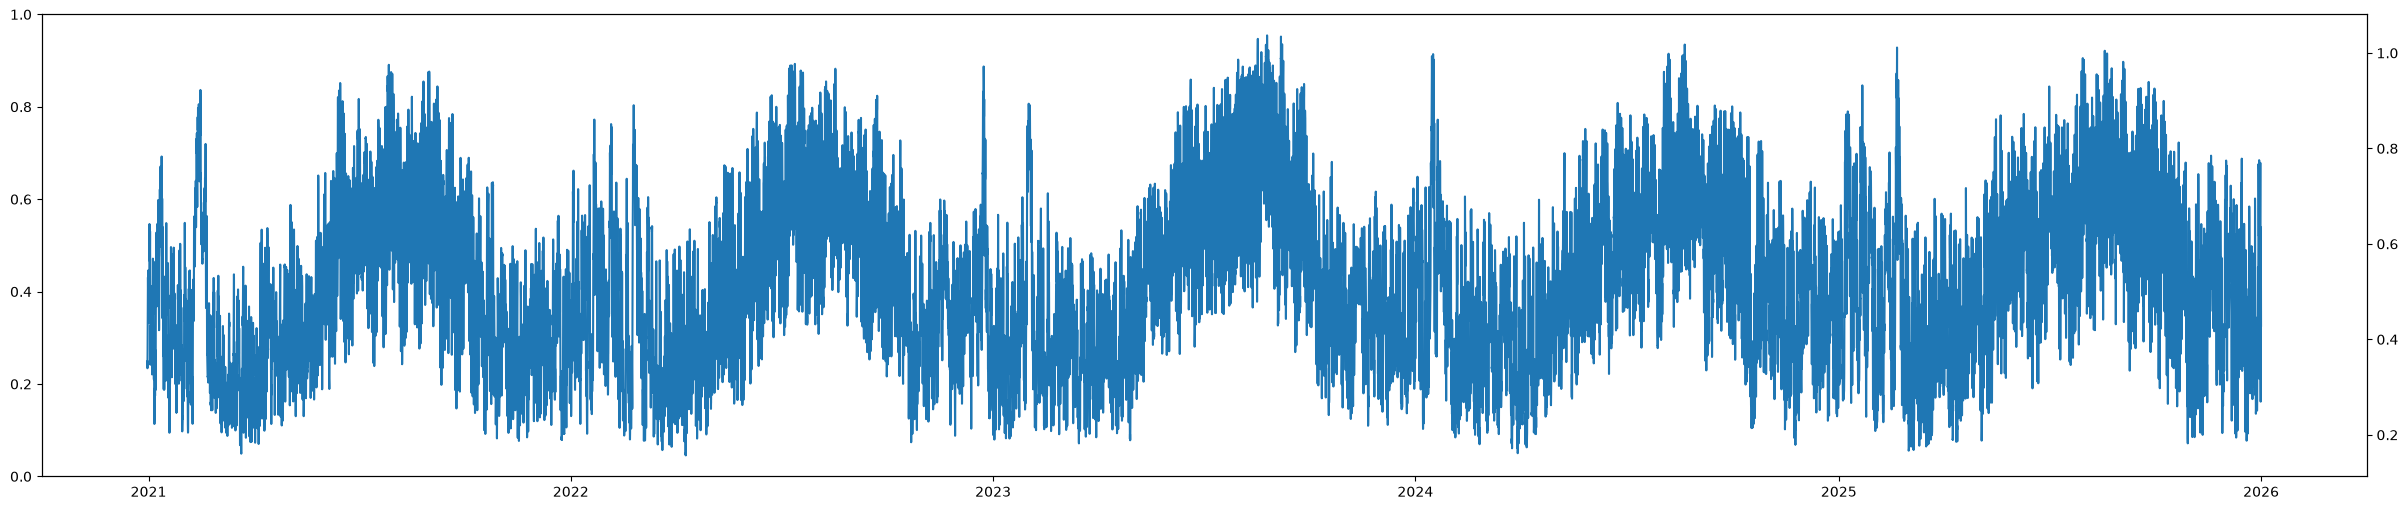

In [ ]:
import matplotlib.pyplot as plt

x = df_price['datetime'] 
fig, ax1 = plt.subplots(figsize=(30, 6))

#ax1.plot(x, df_price['rolling_avg_price'])
#ax1.plot(x, df_price['daily_spread'])
#ax1.set_ylim(0, 1000)

ax2 = ax1.twinx()
ax2.plot(df_metric['datetime'] , df_metric['metric1'])